# Precipitation Hyetograph Comparison

Generate 30 temporal precipitation patterns, write native area precipitation tables through
`RasUnsteady`, and inspect a bounded two-plan forcing diagnostic on copied Davis examples.
These are **precipitation depths per interval**, not upstream discharge hydrographs.

| Stage | Scope of the saved run |
|---|---|
| Pattern generation | Five Atlas14Storm quartiles, four SCS types and one ABM pattern for each of three supplied depths: 30 cases |
| Authoring/readback | 30 plans in three isolated copies of the real Davis project |
| Fresh HEC-RAS computation | Only 10yr Atlas14_AllCases and StormGen_AB50; sequential, two cores |
| Forcing qualification | Failed intended-versus-solver depth agreement; hydraulic ranking withheld and remaining 28 plans uncomputed |

The earlier June 2026 notebook recorded 27 computed cases because its ABM call failed. This
revision replaces that historical comparison with fresh bounded evidence; it does not claim
all 30 cases were computed. Full execution remains available by deliberately setting
`COMPUTE_CASES=None` and allocating the required time.

The supplied 6.94/11.60/17.0-inch depths retain the original comparison inputs. They are
illustrative location/frequency labels, not a newly verified precipitation-frequency study.
DDF data shape the ABM pattern; all methods are scaled to each supplied total. The Houston
patterns applied to Davis demonstrate API mechanics, not site-specific design recommendations.

For spatially varying precipitation, see [722](722_gridded_precipitation_atlas14.ipynb),
[727](727_atlas14_gridded_rain_on_grid_hecras.ipynb) and
[729](729_direct_geotiff_gridded_rain_on_grid.ipynb).
**Experimental forcing demonstration:** the saved runs mechanically completed, but native
cumulative rainfall differs from intended depth. The diagnostic below preserves the mismatch;
it does not establish a valid equal-depth hydraulic comparison.


In [1]:
# =============================================================================
# DEVELOPMENT MODE TOGGLE
# =============================================================================
USE_LOCAL_SOURCE = True  # Set to True for local development, False for pip package

if USE_LOCAL_SOURCE:
    import sys
    from pathlib import Path
    local_path = str(Path.cwd().parent)
    if local_path not in sys.path:
        sys.path.insert(0, local_path)
    print(f"LOCAL SOURCE MODE: Loading from {local_path}/ras_commander")
else:
    print("PIP PACKAGE MODE: Loading installed ras-commander")

# Import ras-commander core
from ras_commander import (
    RasExamples, 
    init_ras_project, 
    ras,
    RasCmdr, 
    RasPlan,
    RasPrj, RasUnsteady
)
from ras_commander.hdf import HdfResultsPlan, HdfMesh

# Import precipitation modules
from ras_commander.precip import (
    StormGenerator,                # Alternating Block Method (for comparison)
    Atlas14Storm,                  # HMS-equivalent Atlas 14 temporal distributions
    ScsTypeStorm,                  # HMS-equivalent SCS Type I/IA/II/III
    ATLAS14_AVAILABLE,             # Availability flag for Atlas14Storm
    SCS_TYPE_AVAILABLE             # Availability flag for ScsTypeStorm
)

import ras_commander
print(f"Loaded ras_commander: {ras_commander.__file__}")

# Check method availability
print(f"\nMethod Availability:")
print(f"  Atlas14Storm (HMS-equiv): {'[OK]' if ATLAS14_AVAILABLE else '[--]'}")
print(f"  ScsTypeStorm (HMS-equiv): {'[OK]' if SCS_TYPE_AVAILABLE else '[--]'}")
print(f"  StormGenerator (Alternating Block): [OK]")

if not (ATLAS14_AVAILABLE and SCS_TYPE_AVAILABLE):
    print("\n  Install hms-commander for HMS-equivalent methods:")
    raise ImportError("Install hms-commander in the active environment before running the full suite")

LOCAL SOURCE MODE: Loading from C:\Users\billk_clb\.codex\workspaces\ras-docs-priority-20260926/ras_commander


Loaded ras_commander: C:\Users\billk_clb\.codex\workspaces\ras-docs-priority-20260926\ras_commander\__init__.py

Method Availability:
  Atlas14Storm (HMS-equiv): [OK]
  ScsTypeStorm (HMS-equiv): [OK]
  StormGenerator (Alternating Block): [OK]


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from datetime import datetime
import shutil
import time

# Configure output
pd.set_option('display.max_rows', 50)
pd.set_option('display.float_format', '{:.4f}'.format)

print("Standard libraries imported successfully")

Standard libraries imported successfully


## Configuration and retained workspace

In [3]:
# Three supplied demonstration depths; verify location/frequency values for a study.
PROJECT_NAME = "Davis"
RAS_VERSION = "7.0"
TEMPLATE_PLAN = "02"
LATITUDE, LONGITUDE = 29.76, -95.37
STATE, REGION = "tx", 3  # Used by Atlas14Storm temporal-distribution lookup.
STORM_DURATION_HOURS = 24
TIME_INTERVAL_MIN = 60
AEP_SUITE = {
    "10yr": {"aep_percent": 10.0, "depth_inches": 6.94},
    "50yr": {"aep_percent": 2.0, "depth_inches": 11.60},
    "100yr": {"aep_percent": 1.0, "depth_inches": 17.0},
}
# The committed run computes only this pair. Set None deliberately for all 30.
COMPUTE_CASES = {("10yr", "Atlas14_AllCases"), ("10yr", "StormGen_AB50")}
NUM_CORES = 2  # Sequential compute; at most two cores total.
repo_root = Path.cwd().parent if Path.cwd().name == "examples" else Path.cwd()
WORKING_DIR = repo_root / "working" / "721" / datetime.now().strftime("%Y%m%dT%H%M%S")
WORKING_DIR.mkdir(parents=True, exist_ok=False)
print(f"Preserved working directory: {WORKING_DIR}")
print(f"Configured cases: {COMPUTE_CASES}")

Preserved working directory: C:\Users\billk_clb\.codex\workspaces\ras-docs-priority-20260926\working\721\20260926T100319
Configured cases: {('10yr', 'StormGen_AB50'), ('10yr', 'Atlas14_AllCases')}


## Generate all 30 temporal patterns

`STATE` and `REGION` select the Atlas14Storm temporal distribution; coordinates select NOAA
DDF inputs for ABM. The methods use different temporal algorithms. No method is endorsed here
for regulatory work, and equal total depth alone does not make every other model assumption equal.

In [4]:
ddf = StormGenerator.download_from_coordinates(
    lat=LATITUDE, lon=LONGITUDE, data="depth", units="english", series="ams"
)
storms_suite = {}
for aep_name, spec in AEP_SUITE.items():
    depth = spec["depth_inches"]
    storms = {}
    for quartile in ["First Quartile", "Second Quartile", "Third Quartile", "Fourth Quartile", "All Cases"]:
        key = "Atlas14_" + quartile.replace(" ", "").replace("Quartile", "Q")
        storms[key] = Atlas14Storm.generate_hyetograph(
            total_depth_inches=depth, state=STATE, region=REGION,
            duration_hours=STORM_DURATION_HOURS, aep_percent=spec["aep_percent"],
            quartile=quartile, interval_minutes=TIME_INTERVAL_MIN,
        )
    for scs_type in ["I", "IA", "II", "III"]:
        storms[f"ScsType_{scs_type}"] = ScsTypeStorm.generate_hyetograph(
            total_depth_inches=depth, scs_type=scs_type, time_interval_min=TIME_INTERVAL_MIN
        )
    storms["StormGen_AB50"] = StormGenerator.generate_hyetograph(
        ddf_data=ddf, total_depth_inches=depth,
        duration_hours=STORM_DURATION_HOURS, position_percent=50,
    )
    # Normalize a t=0 zero row to the writer's end-of-interval convention.
    for name, frame in storms.items():
        frame = frame.copy()
        if frame.hour.iloc[0] == 0:
            assert frame.incremental_depth.iloc[0] == 0
            frame = frame.iloc[1:].reset_index(drop=True)
        assert len(frame) > 1 and frame.hour.iloc[0] > 0
        intervals = np.diff(np.r_[0.0, frame.hour.to_numpy()])
        np.testing.assert_allclose(intervals, intervals[0])
        assert np.isclose(frame.hour.iloc[-1], STORM_DURATION_HOURS)
        np.testing.assert_allclose(frame.incremental_depth.sum(), depth, atol=1e-8)
        np.testing.assert_allclose(frame.cumulative_depth.iloc[-1], depth, atol=1e-8)
        storms[name] = frame
    assert len(storms) == 10
    storms_suite[aep_name] = storms
print(f"Generated {sum(map(len, storms_suite.values()))} complete hyetographs.")
print({aep: len(storms) for aep, storms in storms_suite.items()})

2026-09-26 10:03:19 - ras_commander.precip.StormGenerator - INFO - Downloading Atlas 14 data for (29.76, -95.37)...


2026-09-26 10:03:21 - ras_commander.precip.StormGenerator - INFO - Downloaded Atlas 14 data for region: Texas


2026-09-26 10:03:21 - hms_commander.Atlas14Storm - INFO - Using cached temporal distribution: C:\Users\billk_clb\.hms-commander\atlas14\tx_3_24h_temporal.csv


2026-09-26 10:03:21 - hms_commander.Atlas14Storm - INFO - Parsed 5 quartile tables with 49 time steps each


2026-09-26 10:03:21 - hms_commander.Atlas14Storm - INFO - Generated hyetograph: 25 intervals, 6.940 inches total


...

2026-09-26 10:03:21 - hms_commander.ScsTypeStorm - INFO - Generated SCS Type IA hyetograph: 25 intervals, 17.000000 inches total, peak 2.669 inches


2026-09-26 10:03:21 - hms_commander.ScsTypeStorm - INFO - Generated SCS Type II hyetograph: 25 intervals, 17.000000 inches total, peak 7.276 inches


2026-09-26 10:03:21 - hms_commander.ScsTypeStorm - INFO - Generated SCS Type III hyetograph: 25 intervals, 17.000000 inches total, peak 4.250 inches


2026-09-26 10:03:21 - ras_commander.precip.StormGenerator - INFO - Generated 24-hour hyetograph (peak at 50%, total depth: 17.000000 inches)


Generated 30 complete hyetographs.
{'10yr': 10, '50yr': 10, '100yr': 10}


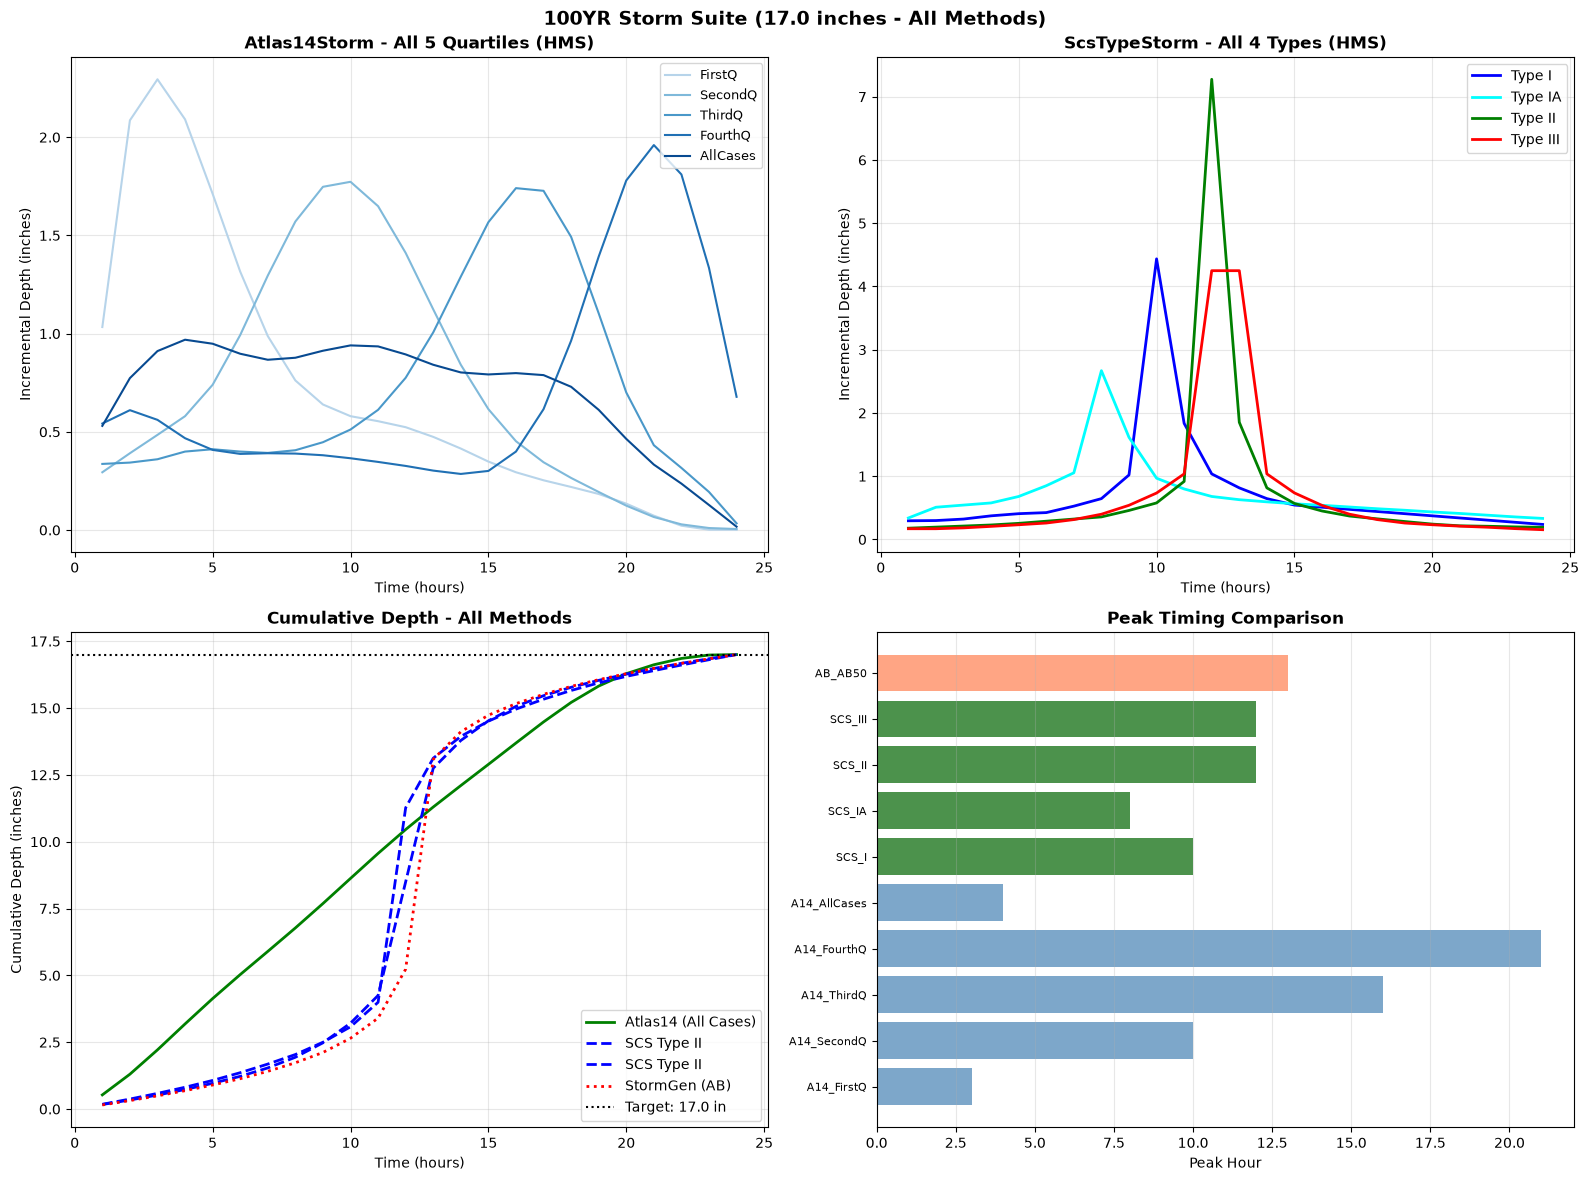

In [5]:
# =============================================================================
# 2.2 Visualize Storm Suite for One AEP
# =============================================================================

# Select AEP to visualize
viz_aep = '100yr'

if viz_aep in storms_suite and len(storms_suite[viz_aep]) > 0:
    storms = storms_suite[viz_aep]
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    axes = axes.flatten()
    
    # Group by method type
    groups = {
        'Atlas14Storm': {k: v for k, v in storms.items() if k.startswith('Atlas14')},
        'ScsTypeStorm': {k: v for k, v in storms.items() if k.startswith('ScsType')},
        'StormGenerator': {k: v for k, v in storms.items() if k.startswith('StormGen')},
    }
    
    # Plot 1: Atlas14Storm quartiles
    ax1 = axes[0]
    if groups['Atlas14Storm']:
        colors = plt.cm.Blues(np.linspace(0.3, 0.9, len(groups['Atlas14Storm'])))
        for (name, hyeto), color in zip(groups['Atlas14Storm'].items(), colors):
            # All methods now return DataFrame - access columns directly
            ax1.plot(hyeto['hour'], hyeto['incremental_depth'], 
                    label=name.replace('Atlas14_', ''), color=color, linewidth=1.5)
        ax1.set_title('Atlas14Storm - All 5 Quartiles (HMS)', fontweight='bold')
        ax1.legend(loc='upper right', fontsize=9)
    ax1.set_xlabel('Time (hours)')
    ax1.set_ylabel('Incremental Depth (inches)')
    ax1.grid(True, alpha=0.3)
    
    # Plot 2: ScsTypeStorm - All Types
    ax2 = axes[1]
    if groups['ScsTypeStorm']:
        colors = ['blue', 'cyan', 'green', 'red']
        for (name, hyeto), color in zip(groups['ScsTypeStorm'].items(), colors):
            ax2.plot(hyeto['hour'], hyeto['incremental_depth'], 
                    label=name.replace('ScsType_', 'Type '), color=color, linewidth=2)
        ax2.set_title('ScsTypeStorm - All 4 Types (HMS)', fontweight='bold')
        ax2.legend(loc='upper right')
    ax2.set_xlabel('Time (hours)')
    ax2.set_ylabel('Incremental Depth (inches)')
    ax2.grid(True, alpha=0.3)
    
    # Plot 3: Cumulative comparison (all methods)
    ax3 = axes[2]
    for name, hyeto in storms.items():
        if 'AllCases' in name:
            ax3.plot(hyeto['hour'], hyeto['cumulative_depth'], 
                    'g-', linewidth=2, label='Atlas14 (All Cases)')
        elif 'ScsType_II' in name:
            ax3.plot(hyeto['hour'], hyeto['cumulative_depth'], 
                    'b--', linewidth=2, label='SCS Type II')
        elif 'StormGen' in name:
            ax3.plot(hyeto['hour'], hyeto['cumulative_depth'], 
                    'r:', linewidth=2, label='StormGen (AB)')
    
    ax3.axhline(AEP_SUITE[viz_aep]['depth_inches'], color='black', linestyle=':', 
                linewidth=1.5, label=f"Target: {AEP_SUITE[viz_aep]['depth_inches']} in")
    ax3.set_title('Cumulative Depth - All Methods', fontweight='bold')
    ax3.set_xlabel('Time (hours)')
    ax3.set_ylabel('Cumulative Depth (inches)')
    ax3.legend(loc='lower right')
    ax3.grid(True, alpha=0.3)
    
    # Plot 4: Peak timing comparison
    ax4 = axes[3]
    storm_names = []
    peak_hours = []
    peak_values = []
    
    for name, hyeto in storms.items():
        storm_names.append(name.replace('Atlas14_', 'A14_').replace('ScsType_', 'SCS_').replace('StormGen_', 'AB_'))
        # Find peak - all DataFrames now
        peak_idx = hyeto['incremental_depth'].idxmax()
        peak_hours.append(hyeto.loc[peak_idx, 'hour'])
        peak_values.append(hyeto.loc[peak_idx, 'incremental_depth'])
    
    colors_bar = ['steelblue' if 'A14' in n else ('darkgreen' if 'SCS' in n else 'coral') for n in storm_names]
    ax4.barh(range(len(storm_names)), peak_hours, color=colors_bar, alpha=0.7)
    ax4.set_yticks(range(len(storm_names)))
    ax4.set_yticklabels(storm_names, fontsize=8)
    ax4.set_xlabel('Peak Hour')
    ax4.set_title('Peak Timing Comparison', fontweight='bold')
    ax4.grid(True, alpha=0.3, axis='x')
    
    plt.suptitle(f'{viz_aep.upper()} Storm Suite ({AEP_SUITE[viz_aep]["depth_inches"]} inches - All Methods)', 
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print(f"No storms available for {viz_aep}")

In [6]:
# =============================================================================
# 2.3 Storm Matrix Summary Table
# =============================================================================

print("\n" + "="*80)
print("STORM MATRIX SUMMARY")
print("="*80)

# Build summary dataframe
rows = []
for aep_name, storms in storms_suite.items():
    for storm_name, hyeto in storms.items():
        # All methods now return DataFrame with standard columns
        total_depth = float(hyeto['cumulative_depth'].iloc[-1])
        peak_intensity = float(hyeto['incremental_depth'].max())
        peak_idx = hyeto['incremental_depth'].idxmax()
        peak_hour = float(hyeto.loc[peak_idx, 'hour'])
        steps = len(hyeto)
        
        # Calculate time interval from hour column spacing
        if len(hyeto) > 1:
            time_step_hr = float(hyeto['hour'].iloc[1] - hyeto['hour'].iloc[0])
        else:
            time_step_hr = 1.0  # Default for single-value case
        
        rows.append({
            'AEP': aep_name,
            'Storm Type': storm_name,
            'Total Depth (in)': total_depth,
            'Peak Interval Depth (in)': peak_intensity,
            'Peak Hour': peak_hour,
            'Steps': steps,
            'Interval (hr)': time_step_hr
        })

storm_summary_df = pd.DataFrame(rows)

# Display summary
print("\nStorm Suite Summary:")
display(storm_summary_df.pivot_table(
    values=['Total Depth (in)', 'Peak Interval Depth (in)', 'Peak Hour'],
    index='Storm Type',
    columns='AEP',
    aggfunc='first'
))

print(f"\nTotal unique storm configurations: {len(storm_summary_df)}")


STORM MATRIX SUMMARY

Storm Suite Summary:


Peak Hour                 Peak Interval Depth (in)         \
AEP                  100yr    10yr    50yr                    100yr   10yr   
Storm Type                                                                   
Atlas14_AllCases    4.0000  4.0000  4.0000                   0.9690 0.3956   
Atlas14_FirstQ      3.0000  3.0000  3.0000                   2.2950 0.9369   
Atlas14_FourthQ    21.0000 21.0000 21.0000                   1.9601 0.8002   
Atlas14_SecondQ    10.0000 10.0000 10.0000                   1.7731 0.7238   
Atlas14_ThirdQ     16.0000 16.0000 16.0000                   1.7408 0.7107   
ScsType_I          10.0000 10.0000 10.0000                   4.4370 1.8113   
ScsType_IA          8.0000  8.0000  8.0000                   2.6690 1.0896   
ScsType_II         12.0000 12.0000 12.0000                   7.2760 2.9703   
ScsType_III        12.0000 12.0000 12.0000                   4.2500 1.7350   
StormGen_AB50      13.0000 13.0000 13.0000                   7.8520 3.2055   

                        Total Depth (in)                 
AEP                50yr            100yr   10yr    50yr  
Storm Type                                               
Atlas14_AllCases 0.6612          17.0000 6.9400 11.6000  
Atlas14_FirstQ   1.5660          17.0000 6.9400 11.6000  
Atlas14_FourthQ  1.3375          17.0000 6.9400 11.6000  
Atlas14_SecondQ  1.2099          17.0000 6.9400 11.6000  
Atlas14_ThirdQ   1.1878          17.0000 6.9400 11.6000  
ScsType_I        3.0276          17.0000 6.9400 11.6000  
ScsType_IA       1.8212          17.0000 6.9400 11.6000  
ScsType_II       4.9648          17.0000 6.9400 11.6000  
ScsType_III      2.9000          17.0000 6.9400 11.6000  
StormGen_AB50    5.3578          17.0000 6.9400 11.6000


Total unique storm configurations: 30


## Write and read back area precipitation tables

The Davis template contains an `area2` precipitation hydrograph. Use the public
`set_precipitation_hyetograph()` writer; do not create unsupported meteorology modes such as
`Hydrograph` or `Hyetograph`. Native `Precipitation Mode=Disable` controls global meteorology
and is retained while editing the separate legacy area precipitation table. The
[HEC boundary-condition manual](https://www.hec.usace.army.mil/confluence/rasdocs/r2dum/latest/boundary-and-initial-conditions-for-2d-flow-areas)
distinguishes area precipitation and global meteorological forcing.

Readback verifies values to the native two-decimal precision. It does not alone prove the
solver consumed rainfall; the selected-pair calculation and output inspection follow.

In [7]:
template_path = RasExamples.extract_project(PROJECT_NAME, output_path=WORKING_DIR, suffix="template")
template_ras = init_ras_project(template_path, RAS_VERSION, ras_object="new", hide_intro=True)
print(template_ras.plan_df[["plan_number", "Plan Title", "unsteady_number"]].to_string(index=False))
storm_projects = {}
authoring_rows = []
for aep_name, storms in storms_suite.items():
    project_path = WORKING_DIR / f"Davis_{aep_name}"
    shutil.copytree(template_path, project_path)
    project = init_ras_project(project_path, RAS_VERSION, ras_object="new", hide_intro=True)
    template_unsteady = project.plan_df.loc[project.plan_df.plan_number == TEMPLATE_PLAN, "unsteady_number"].iloc[0]
    storm_projects[aep_name] = {"path": project_path, "ras": project, "plans": {}}
    for storm_name, hyeto in storms.items():
        # The unchanged Davis plan lasts 36 hours: append an explicit dry tail.
        step_hr = float(hyeto.hour.iloc[1] - hyeto.hour.iloc[0])
        tail_hours = np.arange(float(hyeto.hour.iloc[-1]) + step_hr, 36.0 + step_hr / 2, step_hr)
        tail = pd.DataFrame({"hour": tail_hours, "incremental_depth": 0.0,
                             "cumulative_depth": float(hyeto.cumulative_depth.iloc[-1])})
        hyeto = pd.concat([hyeto, tail], ignore_index=True)
        plan_num = RasPlan.clone_plan(TEMPLATE_PLAN, new_title=storm_name[:32], ras_object=project)
        unsteady_num = RasPlan.clone_unsteady(template_unsteady, new_title=f"{aep_name} {storm_name}"[:32], ras_object=project)
        RasPlan.set_unsteady(plan_num, unsteady_num, ras_object=project)
        unsteady = Path(project.unsteady_df.loc[project.unsteady_df.unsteady_number == unsteady_num, "full_path"].iloc[0])
        native_met = RasUnsteady.get_met_precipitation_config(unsteady, ras_object=project)
        RasUnsteady.set_precipitation_hyetograph(unsteady, hyeto, boundary_name="area2", ras_object=project)
        # Legacy area precipitation is separate from global meteorology. Preserve native state.
        assert RasUnsteady.get_met_precipitation_config(unsteady, ras_object=project) == native_met
        parsed = RasUnsteady.extract_tables(unsteady, ras_object=project)["Precipitation Hydrograph="]["Value"]
        np.testing.assert_allclose(parsed.to_numpy(), hyeto.incremental_depth.to_numpy(), atol=0.00501)
        csv_path = project_path / f"hyetograph_{storm_name}.csv"
        hyeto.to_csv(csv_path, index=False)
        storm_projects[aep_name]["plans"][storm_name] = {
            "plan_number": plan_num, "unsteady_file": unsteady,
            "hyetograph": hyeto, "written_depth_inches": float(parsed.sum()),
        }
        authoring_rows.append({"AEP": aep_name, "method": storm_name, "plan": plan_num,
            "input_depth_in": float(hyeto.incremental_depth.sum()), "written_depth_in": float(parsed.sum()),
            "interval_minutes": float(hyeto.hour.iloc[1] - hyeto.hour.iloc[0]) * 60,
            "global_meteorology_enabled": native_met["enabled"]})
authoring_df = pd.DataFrame(authoring_rows)
assert len(authoring_df) == 30
print("All 30 stage-independent precipitation tables passed public-API readback.")
display(authoring_df)
print("Two-decimal serialization can slightly change total depth; retain both columns.")

2026-09-26 10:03:23 - ras_commander.RasExamples - INFO - Successfully extracted project 'Davis' to Davis_template


2026-09-26 10:03:23 - ras_commander.RasPrj - WARNING - Skipping HDF results summary for plan 02 because hdf is the selected result format


plan_number                Plan Title unsteady_number
         02 Full System ROM with Pump              01


2026-09-26 10:03:23 - ras_commander.RasPrj - WARNING - Skipping HDF results summary for plan 02 because hdf is the selected result format


2026-09-26 10:03:23 - ras_commander.RasPrj - WARNING - Skipping HDF results summary for plan 02 because hdf is the selected result format


...

2026-09-26 10:03:43 - ras_commander.RasPrj - WARNING - Skipping HDF results summary for plan 11 because hdf is the selected result format


2026-09-26 10:03:43 - ras_commander.RasUnsteady - INFO - Updated Precipitation Hydrograph in DavisStormSystem.u11: 36 time steps, interval=1HOUR, total depth=17.0000 inches


All 30 stage-independent precipitation tables passed public-API readback.


,AEP,method,plan,input_depth_in,written_depth_in,interval_minutes,global_meteorology_enabled
0,10yr,Atlas14_FirstQ,01,6.9400,6.9200,60.0000,False
1,10yr,Atlas14_SecondQ,03,6.9400,6.9300,60.0000,False
2,10yr,Atlas14_ThirdQ,04,6.9400,6.9600,60.0000,False
3,10yr,Atlas14_FourthQ,05,6.9400,6.9400,60.0000,False
4,10yr,Atlas14_AllCases,06,6.9400,6.9600,60.0000,False
5,10yr,ScsType_I,07,6.9400,6.9200,60.0000,False
6,10yr,ScsType_IA,08,6.9400,6.9800,60.0000,False
7,10yr,ScsType_II,09,6.9400,6.9400,60.0000,False
8,10yr,ScsType_III,10,6.9400,6.9400,60.0000,False
9,10yr,StormGen_AB50,11,6.9400,6.9500,60.0000,False


Two-decimal serialization can slightly change total depth; retain both columns.


## Compute the selected pair

Every compute goes through `RasCmdr.compute_plan()` with fresh-result inspection. A successful
launcher is not treated as a hydraulic acceptance decision. Existing model geometry, losses,
boundary conditions and the 36-hour simulation window are retained for this bounded comparison.

In [8]:
from datetime import timezone
from ras_commander.hdf import HdfResultsMesh
execution_records = []
computed = {}
for aep_name, project_info in storm_projects.items():
    project = project_info["ras"]
    for storm_name, plan_info in project_info["plans"].items():
        if COMPUTE_CASES is not None and (aep_name, storm_name) not in COMPUTE_CASES:
            continue
        longest = max(len(str(path.resolve())) for path in project_info["path"].rglob("*") if path.is_file())
        assert longest <= 240, f"HEC-RAS path exceeds workspace budget: {longest}"
        started = datetime.now(timezone.utc)
        result = RasCmdr.compute_plan(
            plan_info["plan_number"], ras_object=project,
            num_cores=NUM_CORES, force_rerun=True, verify=True, max_runtime=900,
            hdf_output_variables=["Cell Precipitation Rate", "Cell Cumulative Precipitation"],
        )
        evidence = RasCmdr.inspect_execution_evidence(
            plan_info["plan_number"], ras_object=project, result_modified_after=started, hash_files=True
        )
        errors = evidence.observations["message_error_count"]
        print(f"{aep_name}/{storm_name}: success={result.success}; completion={evidence.mechanical_completion.value}; errors={errors.value}")
        print(result.execution_details)
        assert result.success and evidence.mechanical_completion.value is True
        assert errors.state == "available" and errors.value == 0
        row = project.plan_df.loc[project.plan_df.plan_number == plan_info["plan_number"]].iloc[0]
        hdf = Path(row["HDF_Results_Path"])
        computed[(aep_name, storm_name)] = {"hdf": hdf, "project": project, "info": plan_info}
        execution_records.append({"AEP": aep_name, "method": storm_name, "plan": plan_info["plan_number"],
            "mechanical_completion": evidence.mechanical_completion.value, "message_errors": errors.value,
            "source": str(hdf), "started_utc": started.isoformat()})
execution_df = pd.DataFrame(execution_records)
display(execution_df)
assert len(computed) == (30 if COMPUTE_CASES is None else len(COMPUTE_CASES))

2026-09-26 10:03:43 - ras_commander.RasPlan - INFO - Added HDF output variable 'Cell Precipitation Rate' to plan file: DavisStormSystem.p06


2026-09-26 10:03:43 - ras_commander.RasPlan - INFO - Added HDF output variable 'Cell Cumulative Precipitation' to plan file: DavisStormSystem.p06


2026-09-26 10:08:31 - ras_commander.ExecutionEvidence - INFO - Inspected execution evidence for plan 06 read-only: completion=True, conflicts=0


2026-09-26 10:08:31 - ras_commander.RasPlan - INFO - Added HDF output variable 'Cell Precipitation Rate' to plan file: DavisStormSystem.p11


2026-09-26 10:08:31 - ras_commander.RasPlan - INFO - Added HDF output variable 'Cell Cumulative Precipitation' to plan file: DavisStormSystem.p11


10yr/Atlas14_AllCases: success=True; completion=True; errors=0
{'execution_api': 'ras_cmdr', 'engine_kind': 'executable', 'selected_result_format': 'hdf', 'calculation_attempted': True, 'solver_quiescence_confirmed': True, 'result_artifacts_finalized': True, 'actual_engine_provenance_confirmed': True, 'selected_executable_path': 'C:\\Program Files (x86)\\HEC\\HEC-RAS\\7.0\\Ras.exe', 'selected_executable_sha256': '9990c10531221469bf51a9a62ae91f36ec01e651bed83aadf632e678130ae797', 'launcher_pid': 9452, 'launcher_create_time': 1790431424.9080045, 'launcher_returncode': 0, 'max_runtime_seconds': 900.0, 'launch_details': {'plan_number': '06', 'command': '"C:\\Program Files (x86)\\HEC\\HEC-RAS\\7.0\\Ras.exe" -c "C:\\Users\\billk_clb\\.codex\\workspaces\\ras-docs-priority-20260926\\working\\721\\20260926T100319\\Davis_10yr\\DavisStormSystem.prj" "C:\\Users\\billk_clb\\.codex\\workspaces\\ras-docs-priority-20260926\\working\\721\\20260926T100319\\Davis_10yr\\DavisStormSystem.p06"', 'executable

2026-09-26 10:13:37 - ras_commander.ExecutionEvidence - INFO - Inspected execution evidence for plan 11 read-only: completion=True, conflicts=0


10yr/StormGen_AB50: success=True; completion=True; errors=0
{'execution_api': 'ras_cmdr', 'engine_kind': 'executable', 'selected_result_format': 'hdf', 'calculation_attempted': True, 'solver_quiescence_confirmed': True, 'result_artifacts_finalized': True, 'actual_engine_provenance_confirmed': True, 'selected_executable_path': 'C:\\Program Files (x86)\\HEC\\HEC-RAS\\7.0\\Ras.exe', 'selected_executable_sha256': '9990c10531221469bf51a9a62ae91f36ec01e651bed83aadf632e678130ae797', 'launcher_pid': 5708, 'launcher_create_time': 1790431711.8716016, 'launcher_returncode': 0, 'max_runtime_seconds': 900.0, 'launch_details': {'plan_number': '11', 'command': '"C:\\Program Files (x86)\\HEC\\HEC-RAS\\7.0\\Ras.exe" -c "C:\\Users\\billk_clb\\.codex\\workspaces\\ras-docs-priority-20260926\\working\\721\\20260926T100319\\Davis_10yr\\DavisStormSystem.prj" "C:\\Users\\billk_clb\\.codex\\workspaces\\ras-docs-priority-20260926\\working\\721\\20260926T100319\\Davis_10yr\\DavisStormSystem.p11"', 'executable_pa

,AEP,method,plan,mechanical_completion,message_errors,source,started_utc
0,10yr,Atlas14_AllCases,06,True,0,C:\Users\billk_clb\.codex\workspaces\ras-docs-...,2026-09-26T14:03:43.909021+00:00
1,10yr,StormGen_AB50,11,True,0,C:\Users\billk_clb\.codex\workspaces\ras-docs-...,2026-09-26T14:08:31.425478+00:00


## Inspect effective forcing and volume accounting

The postprocessing cells were rerun against the retained HDF/CSV files after correcting
the exact native dataset names (`Cell Precipitation Rate` and
`Cell Cumulative Precipitation Depth`). No additional solver runs were made.


In [9]:
# Inspect solver-written rainfall and enforce a separate forcing qualification gate.
forcing_rows = []
maxima = {}
effective_curves = {}
for (aep, method), item in computed.items():
    rates = HdfResultsMesh.get_mesh_timeseries(item["hdf"], mesh_name="area2", var="Cell Precipitation Rate", truncate=False)
    cumulative = HdfResultsMesh.get_mesh_timeseries(item["hdf"], mesh_name="area2", var="Cell Cumulative Precipitation Depth", truncate=False)
    assert rates.attrs["units"] == "in/hr" and cumulative.attrs["units"] == "in"
    assert np.isfinite(rates.values).all() and float(rates.max()) > 0
    # Report the positive native-cell totals separately from cells receiving zero rain.
    final = cumulative.isel(time=-1).values
    positive = final[final > 0]
    assert positive.size
    intended = float(item["info"]["hyetograph"].incremental_depth.sum())
    written = item["info"]["written_depth_inches"]
    qualified = bool(np.allclose(positive, written, rtol=0, atol=0.005))
    effective_curves[(aep, method)] = cumulative.max(dim="cell_id")
    maxima[(aep, method)] = HdfResultsMesh.get_mesh_max_ws(item["hdf"])
    print(f"{aep}/{method}: {rates.shape}; units={rates.attrs['units']}; native window={rates.time.values[0]} to {rates.time.values[-1]}")
    print(f"Native positive-rain cells={positive.size}; zero-rain cells={(final == 0).sum()}")
    print("Volume accounting (recorded, without applying a universal acceptance threshold):")
    display(HdfResultsPlan.get_volume_accounting(item["hdf"]))
    forcing_rows.append({"AEP": aep, "method": method, "plan": item["info"]["plan_number"],
        "input_depth_in": intended, "written_depth_in": written,
        "native_positive_cell_min_in": float(positive.min()), "native_positive_cell_max_in": float(positive.max()),
        "native_minus_written_in": float(positive.max()) - written,
        "forcing_qualified": qualified, "peak_rate_in_hr": float(rates.max()),
        "peak_WSE_ft_unqualified": float(maxima[(aep, method)].maximum_water_surface.max())})
assert set(effective_curves) == set(computed)
assert set(maxima) == set(computed)
forcing_df = pd.DataFrame(forcing_rows)
assert not forcing_df.duplicated(["AEP", "method"]).any()
display(forcing_df)
forcing_qualified = bool(forcing_df.forcing_qualified.all())
print("Forcing qualification:", "PASS" if forcing_qualified else "FAIL: native rainfall differs from serialized input; hydraulic ranking withheld.")


10yr/Atlas14_AllCases: (217, 2941); units=in/hr; native window=2000-01-10T12:00:00.000000000 to 2000-01-12T00:00:00.000000000
Native positive-rain cells=2705; zero-rain cells=236
Volume accounting (recorded, without applying a universal acceptance threshold):


,Error,Error Percent,Precipitation Excess (acre feet),Precipitation Excess (inches),Total Boundary Flux of Water In,Total Boundary Flux of Water Out,Vol Accounting in,Volume Ending,Volume Starting
0,-0.127915,0.015998,799.571533,6.66712,799.571533,204.584061,Acre Feet,594.859558,0.0


10yr/StormGen_AB50: (217, 2941); units=in/hr; native window=2000-01-10T12:00:00.000000000 to 2000-01-12T00:00:00.000000000
Native positive-rain cells=2705; zero-rain cells=236
Volume accounting (recorded, without applying a universal acceptance threshold):


,Error,Error Percent,Precipitation Excess (acre feet),Precipitation Excess (inches),Total Boundary Flux of Water In,Total Boundary Flux of Water Out,Vol Accounting in,Volume Ending,Volume Starting
0,0.14236,0.017417,817.36615,6.815497,817.36615,186.374039,Acre Feet,631.13446,0.0


,AEP,method,plan,input_depth_in,written_depth_in,native_positive_cell_min_in,native_positive_cell_max_in,native_minus_written_in,forcing_qualified,peak_rate_in_hr,peak_WSE_ft_unqualified
0,10yr,Atlas14_AllCases,06,6.94,6.96,6.74,6.74,-0.22,False,0.40,53.372066
1,10yr,StormGen_AB50,11,6.94,6.95,6.89,6.89,-0.06,False,3.21,53.589127


Forcing qualification: FAIL: native rainfall differs from serialized input; hydraulic ranking withheld.


## Compare input and effective cumulative rainfall

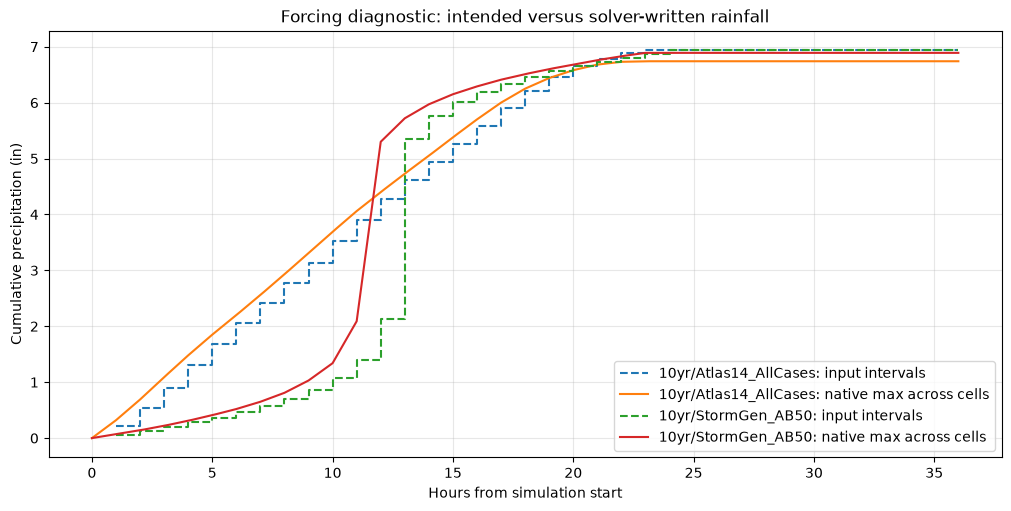

Hydraulic comparison withheld: reconcile the depth/timing mismatch before comparing equal-depth storms.


In [10]:
fig, ax = plt.subplots(figsize=(10, 5), layout="constrained")
for (aep, method), item in computed.items():
    hyeto = item["info"]["hyetograph"]
    ax.step(hyeto.hour, hyeto.cumulative_depth, where="post", linestyle="--", label=f"{aep}/{method}: input intervals")
    native = effective_curves[(aep, method)]
    hours = (native.time.values - native.time.values[0]) / np.timedelta64(1, "h")
    ax.plot(hours, native.values, label=f"{aep}/{method}: native max across cells")
ax.set(xlabel="Hours from simulation start", ylabel="Cumulative precipitation (in)",
       title="Forcing diagnostic: intended versus solver-written rainfall")
ax.legend(); ax.grid(alpha=0.3); plt.show()
if not forcing_qualified:
    print("Hydraulic comparison withheld: reconcile the depth/timing mismatch before comparing equal-depth storms.")
else:
    print("Depth agreement alone does not qualify the model hydraulically; review local results and numerical diagnostics.")


## Interpretation and further work

Both selected 10-year-label plans completed mechanically, but the forcing qualification gate
failed. The hourly native tables cover the unchanged January 10, 2000 12:00 to January 12,
2000 00:00 simulation (36 hours), with a 24-hour storm and an explicit dry tail. The table above
retains generated, two-decimal serialized and native positive-cell cumulative depths in inches.
Native rate output is inches/hour; saved output timestamps are ten minutes apart. Zero-rain
cells are reported separately, rather than silently included in a spatial average.

The public writer documents interval-end input, while its native table serializes only values
and spacing. The first-value/start-time alignment is a **causal hypothesis, not a verified
explanation** of the observed deficit. Do not add an unverified leading value or change native
meteorology flags to hide this result. Qualify native timing and depth conservation on a copied
model before using this recipe for an equal-depth hydraulic comparison. No hydraulic ranking
or design recommendation is supported by these runs.

The generation plots still compare all 30 patterns. The remaining 28 plans were authored and
read back but not computed. Before any study, verify regional depths/distributions, timing,
losses, volume accounting, numerical convergence and decision-location responses. Completion,
zero counted errors and nonzero rainfall alone do not establish engineering acceptability.

All generated CSV, model and result files remain under the printed working directory.
Related examples: [720](720_precipitation_methods_comprehensive.ipynb),
[723](723_storm_generator_abm_validation.ipynb), and [725](725_atlas14_spatial_variance.ipynb).
